In [6]:
# 📚 Book Data Exploration

This notebook is part of a Data Engineering project.  
Goal: Extract, explore, and analyze book data from an external API.

Technologies used:
- Python
- Pandas
- API (Google Books)

SyntaxError: invalid syntax (52688597.py, line 3)

In [1]:
import pandas as pd
import requests

In [2]:
# file path
file_path = "../data/books.csv"

# loading
df = pd.read_csv(file_path, encoding='latin-1', on_bad_lines='skip')

df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPrÃ©,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPrÃ©,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPrÃ©,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPrÃ©,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [3]:
# Basic Data Exploration

# First 5 orws
df.head()

# Column and data type information
df.info()

# Statistical description of numerical columns
df.describe()

# Empty values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  str    
 2   authors             11123 non-null  str    
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  str    
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  str    
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  str    
 11  publisher           11123 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 1.0 MB


bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
  num_pages           0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

Data Cleaning & Preprocessing

This block prepares the dataset for analysis by cleaning and standardizing the data:

1. Duplicate check and removal – ensures that each book is represented only once.
2. Parsing publication dates (publication_date) – using dateutil.parser, all values are converted into a valid datetime format.
3. Creating a new column publication_year – extracts the year from the parsed date for easier aggregation and visualization.
4. Checking data types – confirms that columns are ready for analysis.
5. Text standardization (authors, publisher) – converts all text to lowercase to avoid duplicates caused by case differences.
6. Preview results – displays the first few rows to verify that the cleaning process was successful.

In [4]:
# Data Cleaning & Preprocessing

# 1. Duplicate check
print("Before:", df.duplicated().sum())
df = df.drop_duplicates()
print("After:", df.duplicated().sum())

# 2. Conversion of publication_date to datetime
from dateutil import parser

def parse_date(x):
    try:
        return parser.parse(x)
    except:
        return pd.NaT
    
df['publication_date_parsed'] = df['publication_date'].apply(parse_date)

# 3. New column: year of publication
df['publication_year'] = df['publication_date_parsed'].dt.year

# 4. Checking data types after conversion
print(df.dtypes)

# 5. Text standardization
df['authors'] = df['authors'].str.lower()
df['publisher'] = df['publisher'].str.lower()

# 6. Checking
df.head()


Before: 0
After: 0
bookID                              int64
title                                 str
authors                               str
average_rating                    float64
isbn                                  str
isbn13                              int64
language_code                         str
  num_pages                         int64
ratings_count                       int64
text_reviews_count                  int64
publication_date                      str
publisher                             str
publication_date_parsed    datetime64[us]
publication_year                  float64
dtype: object


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,publication_date_parsed,publication_year
0,1,Harry Potter and the Half-Blood Prince (Harry ...,j.k. rowling/mary grandprã©,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,scholastic inc.,2006-09-16,2006.0
1,2,Harry Potter and the Order of the Phoenix (Har...,j.k. rowling/mary grandprã©,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,scholastic inc.,2004-09-01,2004.0
2,4,Harry Potter and the Chamber of Secrets (Harry...,j.k. rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,scholastic,2003-11-01,2003.0
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,j.k. rowling/mary grandprã©,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,scholastic inc.,2004-05-01,2004.0
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,j.k. rowling/mary grandprã©,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,scholastic,2004-09-13,2004.0


In [5]:
#Data Analysis & Insights

import matplotlib.pyplot as plt
import seaborn as sns

df.describe()

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count,publication_date_parsed,publication_year
count,11123.000000,11123.000000,1.112300e+04,11123.000000,1.112300e+04,11123.000000,11121,11121.000000
mean,21310.856963,3.934075,9.759880e+12,336.405556,1.794285e+04,542.048099,2000-08-29 03:05:33.099541,2000.170668
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000,1900-01-01 00:00:00,1900.000000
25%,10277.500000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000,1998-07-17 00:00:00,1998.000000
50%,20287.000000,3.960000,9.780582e+12,299.000000,7.450000e+02,47.000000,2003-03-01 00:00:00,2003.000000
75%,32104.500000,4.140000,9.780872e+12,416.000000,5.000500e+03,238.000000,2005-10-01 00:00:00,2005.000000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000,2020-03-31 00:00:00,2020.000000
std,13094.727252,0.350485,4.429758e+11,241.152626,1.124992e+05,2576.619589,NaN,8.246168


In [6]:
# Top 10 highets rated boooks

top_books = df.sort_values(by='average_rating', ascending=False).head(10)

top_books[['title', 'average_rating', 'authors']]

,title,average_rating,authors
9324,Tyrannosaurus Wrecks (Stanley #1),5.0,laura driscoll/alisa klayman-grodsky/eric ...
9282,Oliver Wendell Holmes in Paris: Medicine Theo...,5.0,william c. dowling
9720,The Irish Anatomist: A Study of Flann O'Brien,5.0,keith donohue
624,Comoediae 1: Acharenses/Equites/Nubes/Vespae/P...,5.0,aristophanes/f.w. hall/w.m. geldart
6775,Delwau Duon: Peintiadau Nicholas Evans = Symph...,5.0,nicholas evans/rhonda evans
9847,The American Campaign: U.S. Presidential Campa...,5.0,james e. campbell
9893,His Princess Devotional: A Royal Encounter Wit...,5.0,sheri rose shepherd
855,Literature Circle Guide: Bridge to Terabithia:...,5.0,tara maccarthy
786,Willem de Kooning: Late Paintings,5.0,julie sylvester/david sylvester
4125,Zone of the Enders: The 2nd Runner Official St...,5.0,tim bogenn


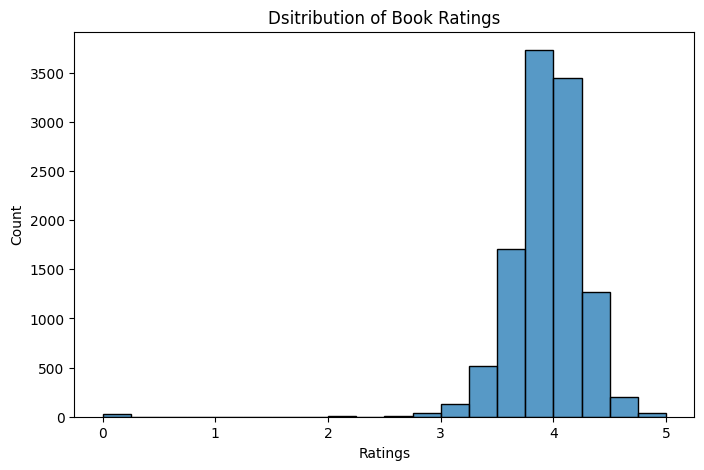

In [7]:
# 3. Distribution of ratings
plt.figure(figsize=(8,5))
sns.histplot(df['average_rating'], bins=20)
plt.title("Dsitribution of Book Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

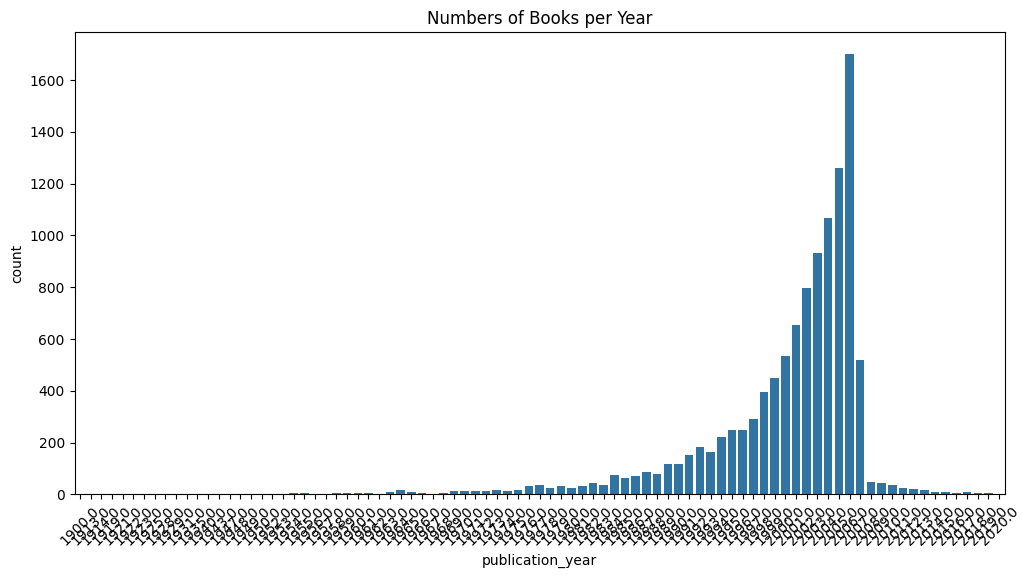

In [8]:
# 4. Books per year
plt.figure(figsize=(12,6))
sns.countplot(x='publication_year', data=df)
plt.xticks(rotation=45)
plt.title("Numbers of Books per Year")
plt.show()


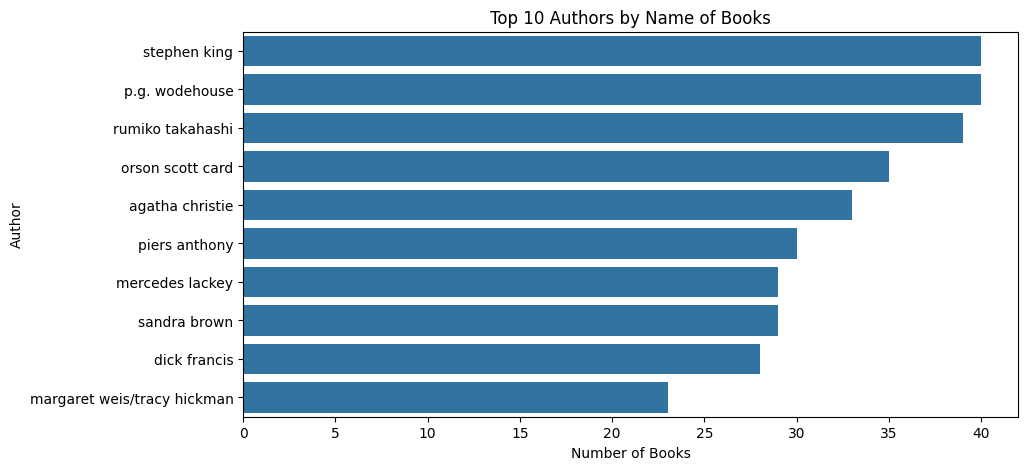

In [9]:
# 5. Top authors
top_authors = df['authors'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title("Top 10 Authors by Name of Books")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.show()

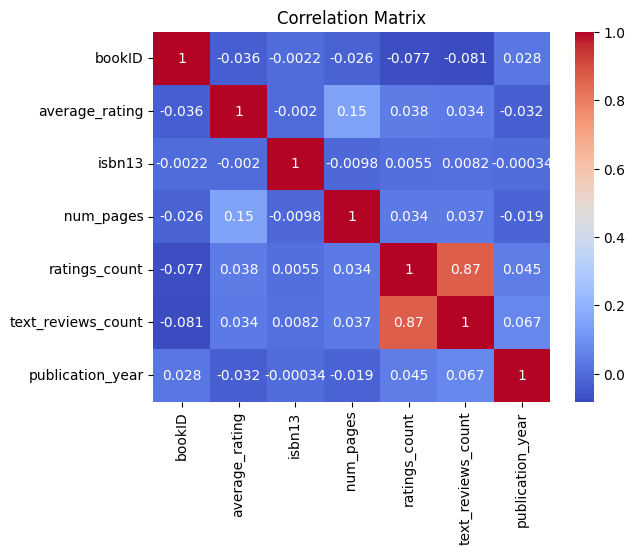

In [10]:
# Relationship Analysis

#Correlation matrix
plt.Figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

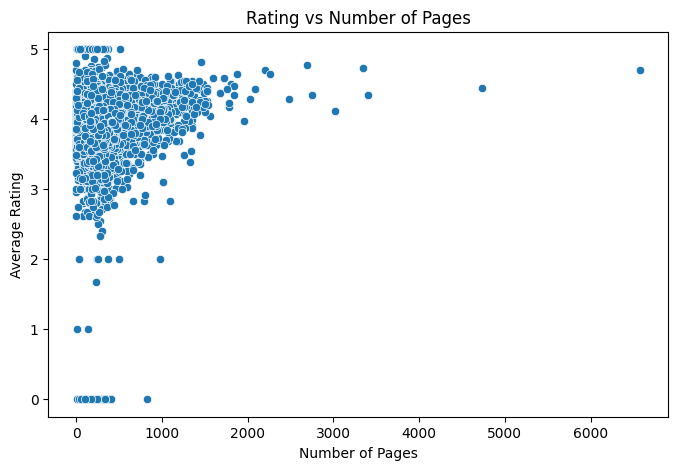

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='num_pages', y='average_rating', data=df)
plt.title("Rating vs Number of Pages")
plt.xlabel("Number of Pages")
plt.ylabel("Average Rating")
plt.show()

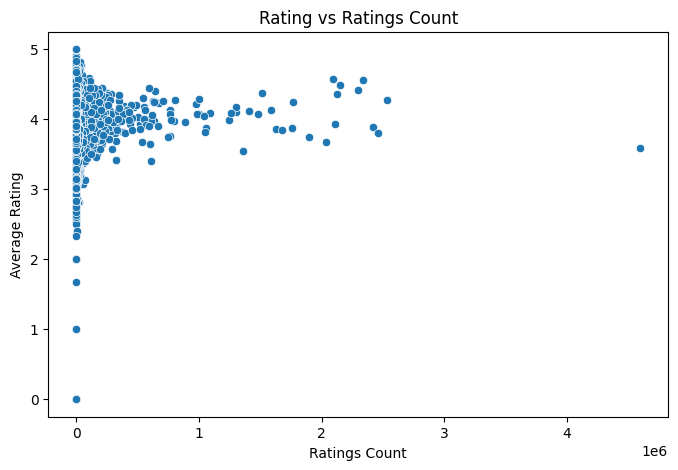

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='ratings_count', y='average_rating', data=df)
plt.title("Rating vs Ratings Count")
plt.xlabel("Ratings Count")
plt.ylabel("Average Rating")
plt.show()

EXPORT

In [25]:
# Save cleaned dataset
df.to_excel("../output/clean_books.xlsx", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [26]:
# Create a clean version of dataset for export

clean_df = df.copy()

# 1. Select only useful columns
clean_df = clean_df[
    [
        'bookID',
        'title',
        'authors',
        'average_rating',
        'num_pages',
        'ratings_count',
        'publication_year',
        'publisher'
    ]
]

# 2. Sort by rating (nice for viewing)
clean_df = clean_df.sort_values(by='average_rating', ascending=False)

# 3. Round ratings for cleaner look
clean_df['average_rating'] = clean_df['average_rating'].round(2)

In [27]:
# Export to Excel (clean version)

clean_df.to_excel("../output/clean_books.xlsx", index=False)

print("Clean Excel exported successfully 🚀")

Clean Excel exported successfully 🚀


In [29]:
with pd.ExcelWriter("../output/clean_books.xlsx", engine='openpyxl') as writer:
    clean_df.to_excel(writer, sheet_name='Books', index=False)